In [1]:
import pandas as pd
# All datasets names
from math_arena_datasets import output_datasets_2025

In [2]:
from typing import Any
from datasets import DatasetDict
data_dict: dict[str, DatasetDict] = {}
from datasets import load_dataset

for dataset_name in output_datasets_2025:
  
  data_dict[dataset_name] = load_dataset(f"{dataset_name}")



In [3]:
all_column_names = set()
for name, dataset in data_dict.items():
  cols = dataset["train"].column_names
  all_column_names = all_column_names.union(cols )
  
all_column_names


{'__index_level_0__',
 'answer',
 'correct',
 'cost',
 'error_judge_1',
 'error_judge_2',
 'gold_answer',
 'grading_details_judge_1',
 'grading_details_judge_2',
 'idx_answer',
 'image',
 'input_cost_per_tokens',
 'input_tokens',
 'max_points_judge_1',
 'max_points_judge_2',
 'model_config',
 'model_name',
 'output_cost_per_tokens',
 'output_tokens',
 'parsed_answer',
 'points_judge_1',
 'points_judge_2',
 'problem',
 'problem_idx',
 'source',
 'user_message'}

In [4]:
from datasets import DatasetDict
def pick_dict_elment(n: int, d: dict[DatasetDict]) -> tuple[str, DatasetDict]: 
  i = 0
  for k,_ in d.items():
    if i==n:
      return k, d[k]

ex_name, ex_dataset = pick_dict_elment(0, data_dict)


ex_dataset["train"].to_pandas()

,problem_idx,problem,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,cost,input_cost_per_tokens,output_cost_per_tokens,source,gold_answer,parsed_answer,correct,__index_level_0__
0,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,22492,0.337827,3.0,15.0,IMO 2025 P6,2112,4048,False,0
1,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,1,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,18982,0.285177,3.0,15.0,IMO 2025 P6,2112,4048,False,1
2,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,2,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,25824,0.387807,3.0,15.0,IMO 2025 P6,2112,4048,False,2
3,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,3,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,22835,0.342972,3.0,15.0,IMO 2025 P6,2112,4048,False,3
4,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,4,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,21121,0.317262,3.0,15.0,IMO 2025 P6,2112,4048,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,11,"Please reason step by step, and put your final...","The value of \(k(n,p)\) is the \(p\)-adic valu...",144,6932,0.104412,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2539
1904,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,12,"Please reason step by step, and put your final...","The value of \(k(n,p)\) is the \(p\)-adic valu...",144,5347,0.080637,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2540
1905,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,13,"Please reason step by step, and put your final...","The value of \(k(n,p)\) is the \(p\)-adic valu...",144,4700,0.070932,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2541
1906,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,14,"Please reason step by step, and put your final...",\boxed{8},144,21562,0.323862,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2542


In [8]:
UNIQUE_PROBLEM_LABEL = "unique_problem_label"
PROBLEM_IDX = "problem_idx"
COMPETITION = "competition"
all_data = []
for competition, dataset in data_dict.items():
  df: pd.DataFrame = dataset["train"].to_pandas()
  df[UNIQUE_PROBLEM_LABEL] = df[PROBLEM_IDX].map(lambda x : f"{competition}: {x}")
  df[COMPETITION] = competition
  all_data.append(df)
data_path = "data/all_answers_pd/all_answers.csv"
# save the data
pd.concat(all_data).to_csv(data_path)

## Drop rows with judge column
We dont want the proof based tasks, since we cannot verify those. So we drop the rows that has a non non value in colun

In [9]:
df = pd.read_csv(data_path)
judge_columns = [x for x in df.columns if "judge" in x]
judge_columns

df = df[df[judge_columns].isna().all(axis=1)]

In [ ]:
df.head()

,Unnamed: 0,problem_idx,problem,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,...,unique_problem_label,points_judge_1,grading_details_judge_1,error_judge_1,max_points_judge_1,points_judge_2,grading_details_judge_2,error_judge_2,max_points_judge_2,image
0,0,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,22492.0,...,MathArena/apex_2025_outputs: 12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,1,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,18982.0,...,MathArena/apex_2025_outputs: 12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,2,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,25824.0,...,MathArena/apex_2025_outputs: 12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,3,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,22835.0,...,MathArena/apex_2025_outputs: 12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,4,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,21121.0,...,MathArena/apex_2025_outputs: 12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Find cols with many missing values

In [10]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_ratio

max_points_judge_2         1.000000
error_judge_2              1.000000
grading_details_judge_2    1.000000
points_judge_2             1.000000
max_points_judge_1         1.000000
error_judge_1              1.000000
grading_details_judge_1    1.000000
points_judge_1             1.000000
source                     0.937979
__index_level_0__          0.937979
image                      0.825250
problem                    0.174750
parsed_answer              0.006079
correct                    0.000000
competition                0.000000
unique_problem_label       0.000000
Unnamed: 0                 0.000000
problem_idx                0.000000
output_cost_per_tokens     0.000000
input_cost_per_tokens      0.000000
cost                       0.000000
output_tokens              0.000000
input_tokens               0.000000
answer                     0.000000
user_message               0.000000
idx_answer                 0.000000
model_config               0.000000
model_name                 0

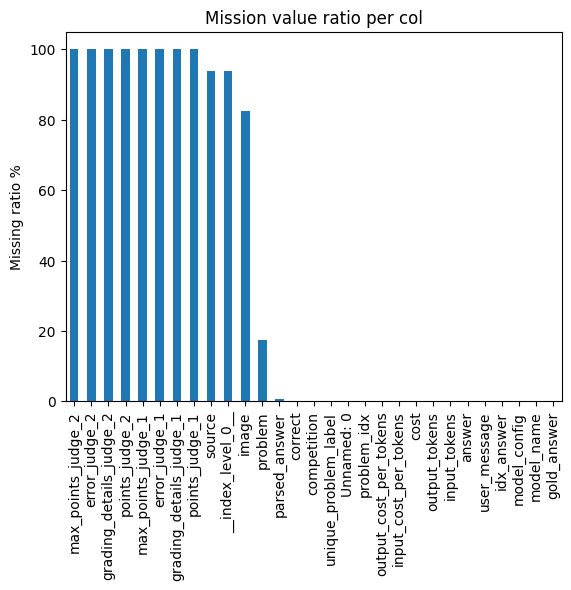

In [11]:
import matplotlib.pyplot as plt 
(missing_ratio*100).plot.bar()
plt.ylabel("Missing ratio %")
plt.title("Mission value ratio per col")
plt.show()

## Drop colulumn with missing value ration over 10%
This will already drop all the values containing proof based questions

In [12]:
cols_to_keep = []
for col, ratio in missing_ratio.to_dict().items():
  if ratio<=0.1 and col not in judge_columns:
    cols_to_keep.append(col)

df_pruned = df[cols_to_keep].reset_index()
df_pruned = df_pruned.drop(["Unnamed: 0"], axis=1)
df_pruned

,index,parsed_answer,correct,competition,unique_problem_label,problem_idx,output_cost_per_tokens,input_cost_per_tokens,cost,output_tokens,input_tokens,answer,user_message,idx_answer,model_config,model_name,gold_answer
0,0,4048,False,MathArena/apex_2025_outputs,MathArena/apex_2025_outputs: 12,12,15.0,3.0,0.337827,22492.0,149.0,"Looking at this problem, I need to find the mi...","Please reason step by step, and put your final...",0,anthropic/claude-sonnet-45,Claude-Sonnet-4.5 (Think),2112
1,1,4048,False,MathArena/apex_2025_outputs,MathArena/apex_2025_outputs: 12,12,15.0,3.0,0.285177,18982.0,149.0,"Looking at this problem, I need to find the mi...","Please reason step by step, and put your final...",1,anthropic/claude-sonnet-45,Claude-Sonnet-4.5 (Think),2112
2,2,4048,False,MathArena/apex_2025_outputs,MathArena/apex_2025_outputs: 12,12,15.0,3.0,0.387807,25824.0,149.0,"Looking at this problem, I need to find the mi...","Please reason step by step, and put your final...",2,anthropic/claude-sonnet-45,Claude-Sonnet-4.5 (Think),2112
3,3,4048,False,MathArena/apex_2025_outputs,MathArena/apex_2025_outputs: 12,12,15.0,3.0,0.342972,22835.0,149.0,"Looking at this problem, I need to find the mi...","Please reason step by step, and put your final...",3,anthropic/claude-sonnet-45,Claude-Sonnet-4.5 (Think),2112
4,4,4048,False,MathArena/apex_2025_outputs,MathArena/apex_2025_outputs: 12,12,15.0,3.0,0.317262,21121.0,149.0,"Looking at this problem, I need to find the mi...","Please reason step by step, and put your final...",4,anthropic/claude-sonnet-45,Claude-Sonnet-4.5 (Think),2112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30759,31197,A,False,MathArena/kangaroo_2025_11-12_outputs,MathArena/kangaroo_2025_11-12_outputs: 10,10,15.0,3.0,0.262941,17160.0,1847.0,\boxed{A},"[{'type': 'text', 'text': 'You are given a Mat...",3,xai/grok-4,Grok 4,E
30760,31198,D,False,MathArena/kangaroo_2025_11-12_outputs,MathArena/kangaroo_2025_11-12_outputs: 6,6,15.0,3.0,0.258036,16833.0,1847.0,\boxed{D},"[{'type': 'text', 'text': 'You are given a Mat...",0,xai/grok-4,Grok 4,A
30761,31199,E,False,MathArena/kangaroo_2025_11-12_outputs,MathArena/kangaroo_2025_11-12_outputs: 6,6,15.0,3.0,0.289806,18951.0,1847.0,\boxed{E},"[{'type': 'text', 'text': 'You are given a Mat...",1,xai/grok-4,Grok 4,A
30762,31200,E,False,MathArena/kangaroo_2025_11-12_outputs,MathArena/kangaroo_2025_11-12_outputs: 6,6,15.0,3.0,0.342036,22433.0,1847.0,\boxed{E},"[{'type': 'text', 'text': 'You are given a Mat...",2,xai/grok-4,Grok 4,A


In [13]:
CORRECT = "correct"
grouped = df_pruned.groupby(UNIQUE_PROBLEM_LABEL)[CORRECT].mean()
grouped

unique_problem_label
MathArena/aime_2025_II_outputs: 1          0.959677
MathArena/aime_2025_II_outputs: 10         0.580645
MathArena/aime_2025_II_outputs: 11         0.403226
MathArena/aime_2025_II_outputs: 12         0.717742
MathArena/aime_2025_II_outputs: 13         0.169355
                                             ...   
MathArena/kangaroo_2025_9-10_outputs: 5         1.0
MathArena/kangaroo_2025_9-10_outputs: 6         1.0
MathArena/kangaroo_2025_9-10_outputs: 7      0.9375
MathArena/kangaroo_2025_9-10_outputs: 8         1.0
MathArena/kangaroo_2025_9-10_outputs: 9         1.0
Name: correct, Length: 337, dtype: object

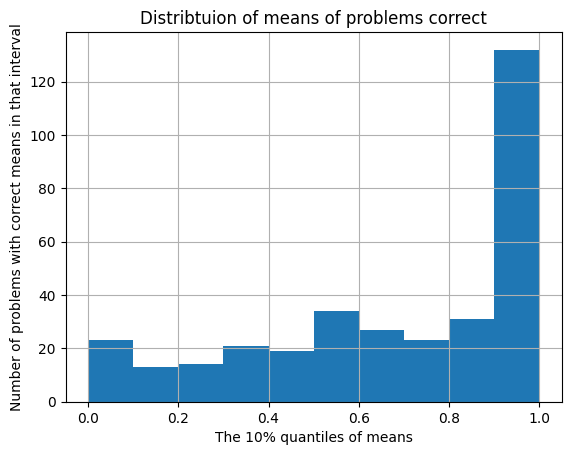

In [14]:
bins = 10
h = grouped.hist(bins=bins)
plt.xlabel(f"The {bins}% quantiles of means")
plt.ylabel("Number of problems with correct means in that interval")
plt.title("Distribtuion of means of problems correct")
plt.show()

### Adding quantile label to dataset

<Axes: title={'center': 'Distribtuion of means of problems correct'}, xlabel='The 10 interval of means', ylabel='Number of problems with correct means in that interval'>

In [15]:
TEN_PERCENT_QUANTILE = "ten_percent_quantile"
quantiles = pd.qcut(grouped,q=10, labels=False, duplicates="drop") +1
q_dict = quantiles.to_dict()
df_pruned[TEN_PERCENT_QUANTILE] = df_pruned[UNIQUE_PROBLEM_LABEL].map(lambda x : q_dict[x])
df_pruned[TEN_PERCENT_QUANTILE]

0        1
1        1
2        1
3        1
4        1
        ..
30759    5
30760    3
30761    3
30762    3
30763    3
Name: ten_percent_quantile, Length: 30764, dtype: int64

In [16]:
ALL_ANSEWERS_PRUNED_PATH = "data/all_answers_pd/all_answers_pruned.csv"
df_pruned.to_csv(ALL_ANSEWERS_PRUNED_PATH)

## First quantile (hardest problems)

In [17]:
q10 = df_pruned[df_pruned[TEN_PERCENT_QUANTILE]==1]

In [18]:
q10.columns

Index(['index', 'parsed_answer', 'correct', 'competition',
       'unique_problem_label', 'problem_idx', 'output_cost_per_tokens',
       'input_cost_per_tokens', 'cost', 'output_tokens', 'input_tokens',
       'answer', 'user_message', 'idx_answer', 'model_config', 'model_name',
       'gold_answer', 'ten_percent_quantile'],
      dtype='object')

## Load the problems data so we can get problem description

In [19]:
from math_arena_datasets import problem_datasets_2025
from datasets import DatasetDict
data_dict: dict[str, DatasetDict] = {}
from datasets import load_dataset

for dataset_name in problem_datasets_2025:
  
  data_dict[dataset_name] = load_dataset(f"{dataset_name}")


IDX = "index"
all_data = []
for competition, dataset in data_dict.items():
  df: pd.DataFrame = dataset["train"].to_pandas()
  df[UNIQUE_PROBLEM_LABEL] = df[PROBLEM_IDX].map(lambda x : f"{competition}: {x}")
  df[COMPETITION] = competition
  all_data.append(df)
data_path = "data/all_problems_pd/all_problems.csv"
# save the data
pd.concat(all_data).to_csv(data_path)
df_problem = pd.read_csv(data_path)
df_problem

,Unnamed: 0,problem_idx,problem,answer,source,__index_level_0__,unique_problem_label,competition,problem_type,points,grading_scheme,sample_solution,sample_grading,image
0,0,1,Let \( f: \mathbb{R} \to \mathbb{R} \) be a co...,4049,All Russian 2025 11.8,0.0,MathArena/apex_2025: 1,MathArena/apex_2025,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,Let $P$ be a polygon formed by the edges of an...,1/2,Turkey TST 2025 P5,1.0,MathArena/apex_2025: 2,MathArena/apex_2025,NaN,NaN,NaN,NaN,NaN,NaN
2,2,4,We call a $n \times n$ table filled with posit...,6266942768,Serbian MO 2025 P6,3.0,MathArena/apex_2025: 4,MathArena/apex_2025,NaN,NaN,NaN,NaN,NaN,NaN
3,3,5,Hannah has a $2024 \times 2025$ rectangle in t...,6,CMM 2025 Individual P10,4.0,MathArena/apex_2025: 5,MathArena/apex_2025,NaN,NaN,NaN,NaN,NaN,NaN
4,4,6,Let $n$ be a positive integer and $p$ be a pri...,138,ELMO Shortlist 2025 N7,5.0,MathArena/apex_2025: 6,MathArena/apex_2025,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,25,26,NaN,B,NaN,NaN,MathArena/kangaroo_2025_11_12: 26,MathArena/kangaroo_2025_11_12,NaN,NaN,NaN,NaN,NaN,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
523,26,27,NaN,C,NaN,NaN,MathArena/kangaroo_2025_11_12: 27,MathArena/kangaroo_2025_11_12,NaN,NaN,NaN,NaN,NaN,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
524,27,28,NaN,B,NaN,NaN,MathArena/kangaroo_2025_11_12: 28,MathArena/kangaroo_2025_11_12,NaN,NaN,NaN,NaN,NaN,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
525,28,29,NaN,D,NaN,NaN,MathArena/kangaroo_2025_11_12: 29,MathArena/kangaroo_2025_11_12,NaN,NaN,NaN,NaN,NaN,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...


In [20]:
import textwrap
def example_q10_proplem(n=0):
  PREFIX = "_outputs"

  example_prop_output = q10.iloc[n]
  example_prop_name: str = example_prop_output[UNIQUE_PROBLEM_LABEL].replace(PREFIX, "")
  example_prop = df_problem[df_problem[UNIQUE_PROBLEM_LABEL]==example_prop_name].iloc[0]
  problem_type = example_prop["problem_type"]
  problem = example_prop["problem"]
  answer = example_prop["answer"]

  s = (
    f"""
    Problem name: {example_prop_name}

    Optional type: {problem_type} 
    
    Problem descr: \n{textwrap.fill(problem, width=80)}

    Answer: {answer}

    """
  )
  print(s)
  return example_prop
example_q10_proplem(0)



    Problem name: MathArena/apex_2025: 12

    Optional type: nan 

    Problem descr: 
Consider a $2025 \times 2025$ grid of unit squares. Matilda wishes to place on
the grid some rectangular tiles, possibly of different sizes, such that each
side of every tile lies on a grid line and every unit square is covered by at
most one tile. Determine the minimum number of tiles Matilda needs to place so
that each row and each column of the grid has exactly one unit square that is
not covered by any tile.

    Answer: 2112

    


Unnamed: 0                                                              8
problem_idx                                                            12
problem                 Consider a $2025 \times 2025$ grid of unit squ...
answer                                                               2112
source                                                        IMO 2025 P6
__index_level_0__                                                    11.0
unique_problem_label                              MathArena/apex_2025: 12
competition                                           MathArena/apex_2025
problem_type                                                          NaN
points                                                                NaN
grading_scheme                                                        NaN
sample_solution                                                       NaN
sample_grading                                                        NaN
image                                 

In [ ]:
list(df_pruned["model_config"].unique())

['anthropic/claude-sonnet-45',
 'deepseek/deepseek_v31',
 'deepseek/deepseek_r1_0528',
 'deepseek/deepseek_v32',
 'gemini/gemini-pro-2.5',
 'openai/gpt-5',
 'openai/oss-120b',
 'openai/gpt-5-mini',
 'openai/gpt-5-agent',
 'glm/glm-46',
 'glm/glm-45',
 'qwen/qwen3_235b_a22b_2507',
 'xai/grok-4-fast-reasoning',
 'xai/grok-4',
 'anthropic/claude-opus-4',
 'anthropic/claude-37',
 'anthropic/claude-35',
 'deepseek/deepseek_distill_14b',
 'deepseek/deepseek_distill_32b',
 'deepseek/deepseek_distill_1.5b',
 'deepseek/deepseek_v3',
 'deepseek/deepseek_distill_70b',
 'deepseek/deepseek_v3_03_24',
 'deepseek/deepseek_r1',
 'llama4/maverick',
 'gemini/gemini-flash-2.5',
 'gemini/gemini-pro-2.5-05-06',
 'gemini/gemini-pro-2.0',
 'gemini/gemini-flash-2.0',
 'gemini/gemini-flash-thinking-2.0',
 'openai/oss-20b',
 'openai/o3',
 'openai/o3-mini--low',
 'openai/o3-mini--medium',
 'openai/o4-mini--medium',
 'openai/o4-mini--high',
 'openai/o4-mini--low',
 'openai/o1',
 'openai/gpt-5-nano',
 'openai/gpt-

In [ ]:
example_prop.replace(PREFIX, "")

'MathArena/apex_2025: 12'

In [ ]:
example_prop

'MathArena/apex_2025_outputs: 12'